# Nodata management

This Jupyter notebook has been created to compare different features with several open source Python librairies for rasters management.

This notebook will particularly focus on how to handle nodata values of a raster object.

The following librairies will be considered :
- rasterio
- rioxarray
- odc-geo
- geoutils

In [1]:
import numpy as np

import rasterio
from rasterio.fill import fillnodata
from rasterio.plot import show

import rioxarray

import odc.geo.xr

import geoutils as gu

import matplotlib.pyplot as plt

import dask

## Nodata interpolation

Nodata interpolation is only available in rasterio and rioxarray librairies.

This method is used to fill gaps where data is missing, to produce cleaner visualizations. Different methods can be used to perform the interpolation : linear, nearest, cubic...

In this example we will work on a raster image that has some missing rows.

In [2]:
#path to the raster object with missing values
raster_path = "../data/odessa_subset_nodata.tif"

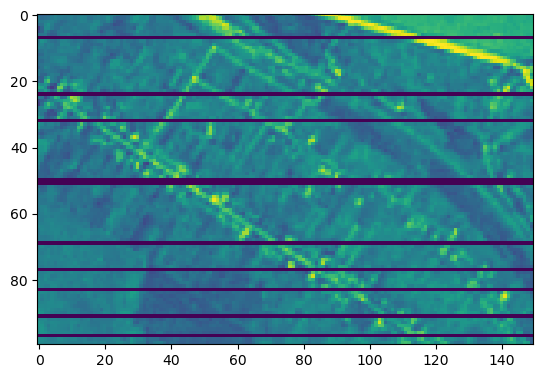

<Axes: >

In [38]:
ds_rasterio = rasterio.open(raster_path)
show(ds_rasterio.read(1))

### • rasterio

With rasterio, we will use the *.fillnodata()* function to perform the interpolation : https://rasterio.readthedocs.io/en/latest/api/rasterio.fill.html

In [22]:
with rasterio.open(raster_path) as src:
    b1 = src.read(1) #first band
    nodata = src.nodata

In [23]:
b1

array([[ 91,  78,  83, ..., 163, 157, 159],
       [102,  88,  92, ..., 157, 152, 157],
       [107, 105, 110, ..., 152, 156, 156],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [126, 124, 119, ..., 135,  93,  78],
       [121, 119, 115, ..., 149, 140,  80]], shape=(100, 150), dtype=uint8)

In [24]:
ds_interp = fillnodata(b1)

ValueError: An mask array is required

rasterio is asking for a mask for where to apply the interpolation, so we will create a mask containing all the nodata values :

In [26]:
mask_nodata = (b1 == nodata)

In [27]:
mask_nodata

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(100, 150))

rasterio will try to interpolate all pixels with the value 0 (or False). Since in our case we have the opposite (missing values marked as True (or 1)), we need to reverse our array with the function np.invert() :

In [30]:
mask_nodata = np.invert(mask_nodata)

In [31]:
mask_nodata

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [False, False, False, ..., False, False, False],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(100, 150))

Our mask is now ready to be used with the *.fillnodata()* function :

In [32]:
ds_interp = fillnodata(b1, mask=mask_nodata)

In [33]:
ds_interp

array([[ 91,  78,  83, ..., 163, 157, 159],
       [102,  88,  92, ..., 157, 152, 157],
       [107, 105, 110, ..., 152, 156, 156],
       ...,
       [127, 126, 120, ..., 102,  90,  89],
       [126, 124, 119, ..., 135,  93,  78],
       [121, 119, 115, ..., 149, 140,  80]], shape=(100, 150), dtype=uint8)

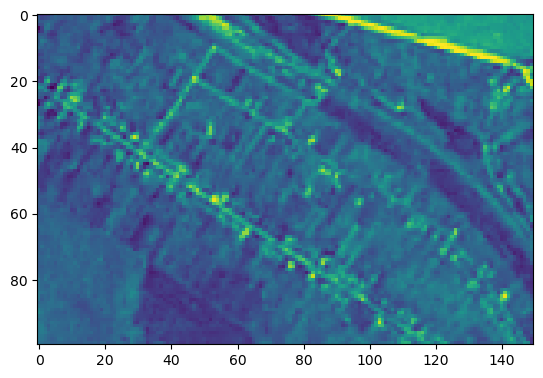

In [35]:
plt.imshow(ds_interp)
plt.show()

### • rioxarray

With rioxarray, we will use the *interpolate_na()* method to perform nodata interpolation : https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.raster_array.RasterArray.interpolate_na

In [54]:
da_rxr = rioxarray.open_rasterio(raster_path)

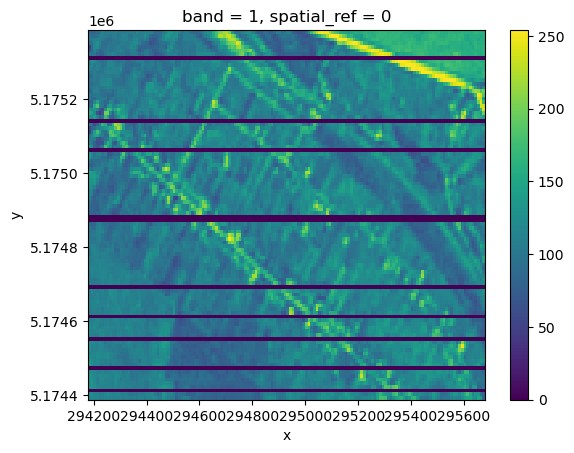

In [55]:
da_rxr.sel(band=1).plot()
plt.show()

In [56]:
da_rxr

<xarray.DataArray (band: 3, y: 100, x: 150)> Size: 45kB
[45000 values with dtype=uint8]
Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 1kB 2.942e+05 2.942e+05 ... 2.957e+05 2.957e+05
  * y            (y) float64 800B 5.175e+06 5.175e+06 ... 5.174e+06 5.174e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        255
    STATISTICS_MEAN:           84.532974253614
    STATISTICS_MINIMUM:        4
    STATISTICS_STDDEV:         57.209552559308
    STATISTICS_VALID_PERCENT:  100
    _FillValue:                0
    scale_factor:              1.0
    add_offset:                0.0

In [71]:
da_rxr.values

array([[[ 91,  78,  83, ..., 163, 157, 159],
        [102,  88,  92, ..., 157, 152, 157],
        [107, 105, 110, ..., 152, 156, 156],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [126, 124, 119, ..., 135,  93,  78],
        [121, 119, 115, ..., 149, 140,  80]],

       [[100, 103, 103, ..., 150, 148, 153],
        [118, 112, 106, ..., 147, 152, 148],
        [132, 122, 111, ..., 144, 143, 148],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [105, 107, 119, ..., 149, 118, 102],
        [100, 103, 114, ..., 146, 128,  98]],

       [[ 64,  53,  59, ..., 122, 123, 118],
        [ 77,  65,  67, ..., 122, 117, 119],
        [ 85,  81,  84, ..., 125, 125, 121],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [ 84, 100,  88, ..., 117,  88,  64],
        [ 81,  95,  93, ..., 127,  97,  71]]],
      shape=(3, 100, 150), dtype=uint8)

With rioxarray, we don't need to specify the mask on where to apply the interpolation :

In [89]:
rxr_interp = da_rxr.rio.interpolate_na()

In [90]:
rxr_interp.values

array([[[ 91.,  78.,  83., ..., 163., 157., 159.],
        [102.,  88.,  92., ..., 157., 152., 157.],
        [107., 105., 110., ..., 152., 156., 156.],
        ...,
        [126., 124., 119., ..., 135.,  93.,  78.],
        [126., 124., 119., ..., 135.,  93.,  78.],
        [121., 119., 115., ..., 149., 140.,  80.]],

       [[100., 103., 103., ..., 150., 148., 153.],
        [118., 112., 106., ..., 147., 152., 148.],
        [132., 122., 111., ..., 144., 143., 148.],
        ...,
        [105., 107., 119., ..., 149., 118., 102.],
        [105., 107., 119., ..., 149., 118., 102.],
        [100., 103., 114., ..., 146., 128.,  98.]],

       [[ 64.,  53.,  59., ..., 122., 123., 118.],
        [ 77.,  65.,  67., ..., 122., 117., 119.],
        [ 85.,  81.,  84., ..., 125., 125., 121.],
        ...,
        [ 84., 100.,  88., ..., 117.,  88.,  64.],
        [ 84., 100.,  88., ..., 117.,  88.,  64.],
        [ 81.,  95.,  93., ..., 127.,  97.,  71.]]], shape=(3, 100, 150))

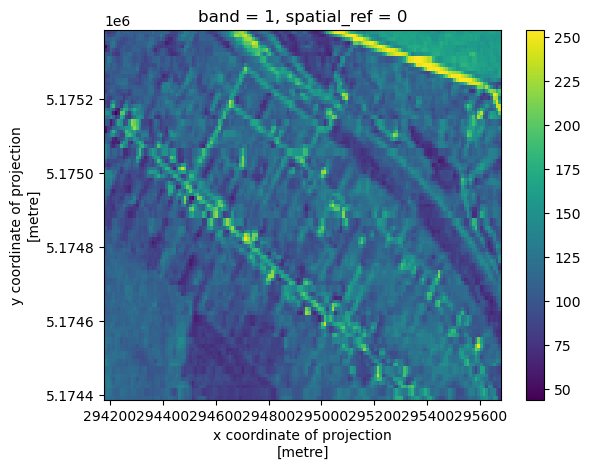

In [91]:
rxr_interp.sel(band=1).plot()
plt.show()

We can finally compare the nodata interpolation results with rasterio and rioxarray :

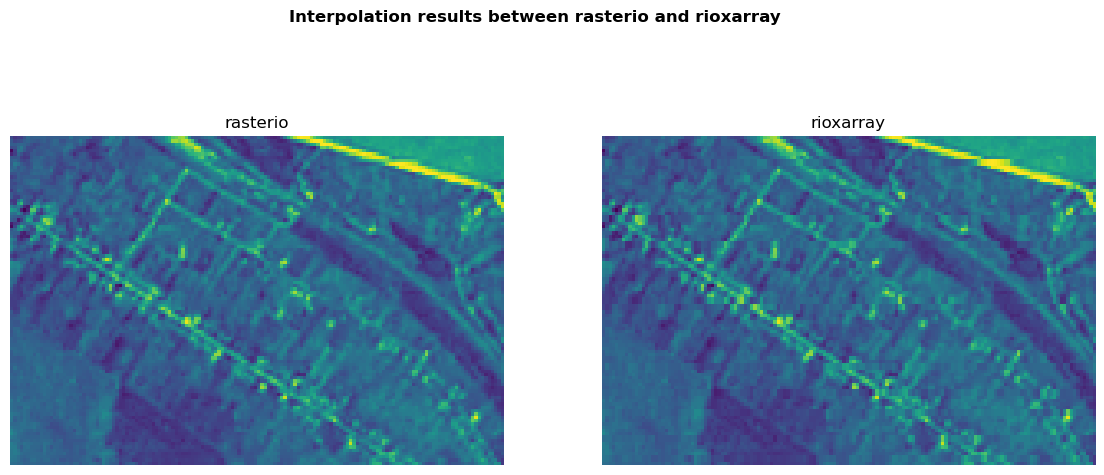

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle("Interpolation results between rasterio and rioxarray", fontweight="bold")

#rasterio interp
axes[0].imshow(ds_interp, cmap='viridis')
axes[0].set_title("rasterio")
axes[0].axis("off")

#rioxarray interp
axes[1].imshow(rxr_interp.sel(band=1), cmap='viridis')
axes[1].set_title("rioxarray")
axes[1].axis("off")

plt.show()

## Nodata handling

### • rasterio

With rasterio, it is possible to create numpy masked arrays to handle missing values.

When creating the array, we need to pass the argument "masked=True" as follows :

In [8]:
with rasterio.open(raster_path) as src:
    arr_masked = src.read(1, masked=True)

In [10]:
print(type(arr_masked))

<class 'numpy.ma.MaskedArray'>


We can use *.mask* to get the boolean matrix ("True" if the pixel is masked) :

In [12]:
print(arr_masked.mask)

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [ True  True  True ...  True  True  True]
 [False False False ... False False False]
 [False False False ... False False False]]


And *.data* allows to check the actual array :

In [11]:
print(arr_masked.data)

[[ 91  78  83 ... 163 157 159]
 [102  88  92 ... 157 152 157]
 [107 105 110 ... 152 156 156]
 ...
 [  0   0   0 ...   0   0   0]
 [126 124 119 ... 135  93  78]
 [121 119 115 ... 149 140  80]]


### • rioxarray

Using rioxarray, we can convert missing values to NaNs as follows :

In [19]:
da_rxr = rioxarray.open_rasterio(raster_path)

We can filter missing values with *.where()* :

In [25]:
da_rxr = da_rxr.where(da_rxr != 0)

In [39]:
da_rxr.values

array([[[ 91.,  78.,  83., ..., 163., 157., 159.],
        [102.,  88.,  92., ..., 157., 152., 157.],
        [107., 105., 110., ..., 152., 156., 156.],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [126., 124., 119., ..., 135.,  93.,  78.],
        [121., 119., 115., ..., 149., 140.,  80.]],

       [[100., 103., 103., ..., 150., 148., 153.],
        [118., 112., 106., ..., 147., 152., 148.],
        [132., 122., 111., ..., 144., 143., 148.],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [105., 107., 119., ..., 149., 118., 102.],
        [100., 103., 114., ..., 146., 128.,  98.]],

       [[ 64.,  53.,  59., ..., 122., 123., 118.],
        [ 77.,  65.,  67., ..., 122., 117., 119.],
        [ 85.,  81.,  84., ..., 125., 125., 121.],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ 84., 100.,  88., ..., 117.,  88.,  64.],
        [ 81.,  95.,  93., ..., 127.,  97.,  71.]]],
      shape=(3, 100, 150), dtype=floa

The second option to handle missing values is to open the raster with the argument *mask_and_scale=True* as follows :

In [41]:
da_rxr_masked = rioxarray.open_rasterio(raster_path, mask_and_scale=True)

In [42]:
da_rxr_masked.rio.nodata

np.float32(nan)

In [43]:
da_rxr_masked.values

array([[[ 91.,  78.,  83., ..., 163., 157., 159.],
        [102.,  88.,  92., ..., 157., 152., 157.],
        [107., 105., 110., ..., 152., 156., 156.],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [126., 124., 119., ..., 135.,  93.,  78.],
        [121., 119., 115., ..., 149., 140.,  80.]],

       [[100., 103., 103., ..., 150., 148., 153.],
        [118., 112., 106., ..., 147., 152., 148.],
        [132., 122., 111., ..., 144., 143., 148.],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [105., 107., 119., ..., 149., 118., 102.],
        [100., 103., 114., ..., 146., 128.,  98.]],

       [[ 64.,  53.,  59., ..., 122., 123., 118.],
        [ 77.,  65.,  67., ..., 122., 117., 119.],
        [ 85.,  81.,  84., ..., 125., 125., 121.],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ 84., 100.,  88., ..., 117.,  88.,  64.],
        [ 81.,  95.,  93., ..., 127.,  97.,  71.]]],
      shape=(3, 100, 150), dtype=floa

### • odc-geo

conversion to float + NaNs

In [76]:
ds_odcgeo = rioxarray.open_rasterio(raster_path)

In [77]:
ds_odcgeo.rio.nodata

np.uint8(0)

We can use *.where()* to filter the missing values by NaN :

In [82]:
ds_odcgeo.where(da != 0)

<xarray.DataArray (band: 3, y: 100, x: 150)> Size: 180kB
array([[[ 91.,  78.,  83., ..., 163., 157., 159.],
        [102.,  88.,  92., ..., 157., 152., 157.],
        [107., 105., 110., ..., 152., 156., 156.],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [126., 124., 119., ..., 135.,  93.,  78.],
        [121., 119., 115., ..., 149., 140.,  80.]],

       [[100., 103., 103., ..., 150., 148., 153.],
        [118., 112., 106., ..., 147., 152., 148.],
        [132., 122., 111., ..., 144., 143., 148.],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [105., 107., 119., ..., 149., 118., 102.],
        [100., 103., 114., ..., 146., 128.,  98.]],

       [[ 64.,  53.,  59., ..., 122., 123., 118.],
        [ 77.,  65.,  67., ..., 122., 117., 119.],
        [ 85.,  81.,  84., ..., 125., 125., 121.],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ 84., 100.,  88., ..., 117.,  88.,  64.],
        [ 81.,  95.,  93., ..., 127.,  97.,  71.]]],
      shape=(3, 100, 150), dtype=float32)
Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 1kB 2.942e+05 2.942e+05 ... 2.957e+05 2.957e+05
  * y            (y) float64 800B 5.175e+06 5.175e+06 ... 5.174e+06 5.174e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        255
    STATISTICS_MEAN:           84.532974253614
    STATISTICS_MINIMUM:        4
    STATISTICS_STDDEV:         57.209552559308
    STATISTICS_VALID_PERCENT:  100
    _FillValue:                0
    scale_factor:              1.0
    add_offset:                0.0

In [81]:
ds_odcgeo.data

array([[[ 91,  78,  83, ..., 163, 157, 159],
        [102,  88,  92, ..., 157, 152, 157],
        [107, 105, 110, ..., 152, 156, 156],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [126, 124, 119, ..., 135,  93,  78],
        [121, 119, 115, ..., 149, 140,  80]],

       [[100, 103, 103, ..., 150, 148, 153],
        [118, 112, 106, ..., 147, 152, 148],
        [132, 122, 111, ..., 144, 143, 148],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [105, 107, 119, ..., 149, 118, 102],
        [100, 103, 114, ..., 146, 128,  98]],

       [[ 64,  53,  59, ..., 122, 123, 118],
        [ 77,  65,  67, ..., 122, 117, 119],
        [ 85,  81,  84, ..., 125, 125, 121],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [ 84, 100,  88, ..., 117,  88,  64],
        [ 81,  95,  93, ..., 127,  97,  71]]],
      shape=(3, 100, 150), dtype=uint8)

### • geoutils

geoutils has a function *set_nodata()* to handle missing values : https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Raster.set_nodata.html#geoutils.Raster.set_nodata

In [61]:
gu_rast = gu.Raster(raster_path)

In [62]:
gu_rast.data

masked_array(
  data=[[[91, 78, 83, ..., 163, 157, 159],
         [102, 88, 92, ..., 157, 152, 157],
         [107, 105, 110, ..., 152, 156, 156],
         ...,
         [--, --, --, ..., --, --, --],
         [126, 124, 119, ..., 135, 93, 78],
         [121, 119, 115, ..., 149, 140, 80]],

        [[100, 103, 103, ..., 150, 148, 153],
         [118, 112, 106, ..., 147, 152, 148],
         [132, 122, 111, ..., 144, 143, 148],
         ...,
         [--, --, --, ..., --, --, --],
         [105, 107, 119, ..., 149, 118, 102],
         [100, 103, 114, ..., 146, 128, 98]],

        [[64, 53, 59, ..., 122, 123, 118],
         [77, 65, 67, ..., 122, 117, 119],
         [85, 81, 84, ..., 125, 125, 121],
         ...,
         [--, --, --, ..., --, --, --],
         [84, 100, 88, ..., 117, 88, 64],
         [81, 95, 93, ..., 127, 97, 71]]],
  mask=[[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., Fal

We can use *.get_nanarray()* to get NaN array from the raster :

In [50]:
gu_rast.get_nanarray()

array([[[ 91.,  78.,  83., ..., 163., 157., 159.],
        [102.,  88.,  92., ..., 157., 152., 157.],
        [107., 105., 110., ..., 152., 156., 156.],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [126., 124., 119., ..., 135.,  93.,  78.],
        [121., 119., 115., ..., 149., 140.,  80.]],

       [[100., 103., 103., ..., 150., 148., 153.],
        [118., 112., 106., ..., 147., 152., 148.],
        [132., 122., 111., ..., 144., 143., 148.],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [105., 107., 119., ..., 149., 118., 102.],
        [100., 103., 114., ..., 146., 128.,  98.]],

       [[ 64.,  53.,  59., ..., 122., 123., 118.],
        [ 77.,  65.,  67., ..., 122., 117., 119.],
        [ 85.,  81.,  84., ..., 125., 125., 121.],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ 84., 100.,  88., ..., 117.,  88.,  64.],
        [ 81.,  95.,  93., ..., 127.,  97.,  71.]]],
      shape=(3, 100, 150), dtype=floa

In [63]:
gu_rast.set_nodata(None)

In [64]:
gu_rast.data

masked_array(
  data=[[[91, 78, 83, ..., 163, 157, 159],
         [102, 88, 92, ..., 157, 152, 157],
         [107, 105, 110, ..., 152, 156, 156],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [126, 124, 119, ..., 135, 93, 78],
         [121, 119, 115, ..., 149, 140, 80]],

        [[100, 103, 103, ..., 150, 148, 153],
         [118, 112, 106, ..., 147, 152, 148],
         [132, 122, 111, ..., 144, 143, 148],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [105, 107, 119, ..., 149, 118, 102],
         [100, 103, 114, ..., 146, 128, 98]],

        [[64, 53, 59, ..., 122, 123, 118],
         [77, 65, 67, ..., 122, 117, 119],
         [85, 81, 84, ..., 125, 125, 121],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [84, 100, 88, ..., 117, 88, 64],
         [81, 95, 93, ..., 127, 97, 71]]],
  mask=[[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],